# Beads: a volatile source, discrete evidence, a stabilizing bound

A jar draws colored beads one at a time; the jar's majority color has probability `p` (`p=0.8` throughout, following the manuscript this project is built around). The jar switches to the other jar with probability `h` on every draw — the observer never sees the switch, only the beads, and has to track which jar is currently active.

This notebook has three parts: **foundations** (the exact IB derivation for this task — quantization, the closed-form transition, hazard dependence, the cost of recursion), **single-decision dynamics** (what the capacity-limited process looks like moment to moment, on one trial), and **testable predictions**. General IB theory shared across all four tasks in this series (what `R` is, why quantization rather than blur, the geometric upper-envelope argument) is in `00_overview.ipynb` and not repeated here.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import numpy as np
import itertools
import matplotlib.pyplot as plt

from ib_core import (
    hmm_window, collapse, ba, beta_critical_binary,
    fsm_scores, optimal_recursive_fsm,
)
from intuitions import (
    simulate_switching_sequence, bead_levels, emit_discrete, llr_table,
    glaze_psi, glaze_trajectory, get_optimal_fsm, simulate_ladder_path,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 13,
})

NORM_COLOR = "#2b6cb0"
LADDER_COLORS = {2: "#c53030", 4: "#dd6b20", 8: "#d69e2e"}
SHADE_COLOR = "#ebf4ff"

h = 0.01
p_bead = 0.8

## 1. Foundations

### 1.1. The normative solution

Glaze et al. (2015) derive the exact normative solution: a log-posterior-odds belief `L_t` (positive = "probably jar 1") updated by

```
L_t = psi(L_{t-1}) + LLR(bead_t)
```

`LLR(bead_t) = log[p(bead|jar 1) / p(bead|jar 0)]` -- the log-likelihood ratio (LLR) -- is a fixed number per bead color (`+-log(p/(1-p)) = +-log4` here). `psi` is a nonlinear discount that leaks old evidence back toward zero — it is what makes the belief track a *switching* source rather than integrate forever — and it has a fixed point: no matter how much evidence piles up in one direction, `L_t` never exceeds `+-log[(1-h)/h]`. This is the **stabilizing bound**, and it exists precisely because the source can switch; a hazard-free (`h=0`) process would have no such ceiling (that limit is exactly the DDM of `03_ddm.ipynb`).

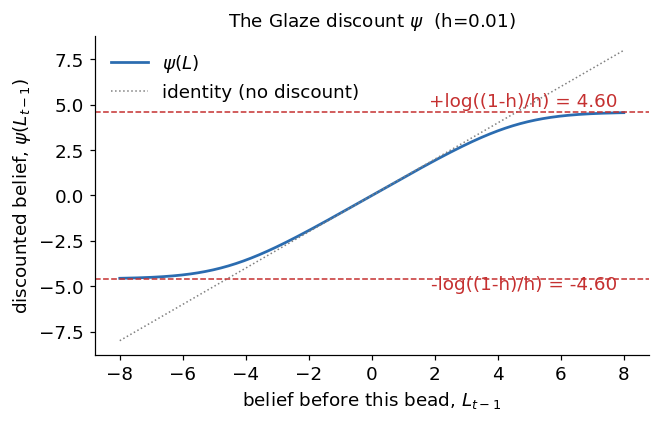

In [2]:
h = 0.01
p_bead = 0.8
L_grid = np.linspace(-8, 8, 400)
psiL = glaze_psi(L_grid, h)
bound = np.log((1 - h) / h)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(L_grid, psiL, color=NORM_COLOR, lw=1.8, label=r"$\psi(L)$")
ax.plot(L_grid, L_grid, color="gray", ls=":", lw=1, label="identity (no discount)")
ax.axhline(bound, color="#c53030", ls="--", lw=1)
ax.axhline(-bound, color="#c53030", ls="--", lw=1)
ax.text(7.8, bound + 0.3, f"+log((1-h)/h) = {bound:.2f}", fontsize=12, color="#c53030", ha="right")
ax.text(7.8, -bound - 0.6, f"-log((1-h)/h) = {-bound:.2f}", fontsize=12, color="#c53030", ha="right")
ax.set_xlabel(r"belief before this bead, $L_{t-1}$")
ax.set_ylabel(r"discounted belief, $\psi(L_{t-1})$")
ax.set_title(f"The Glaze discount $\\psi$  (h={h})")
ax.legend(frameon=False, fontsize=12, loc="upper left")
fig.tight_layout()
plt.show()

### 1.2. The quantization result

`00_overview.ipynb` derives, in general, why the IB-optimal `R` is discrete (an upper envelope of straight lines) rather than a blurred version of `L_t`. Here that general fact is turned into a concrete object: the actual frontier, swept over the trade-off parameter `beta`, using the exact windowed HMM enumeration (`ib_core.hmm_window`) and Blahut-Arimoto (`ib_core.ba`). A window of `W=12` observations is used throughout this section — large enough that the windowed frontier is indistinguishable from the (unbounded-memory) belief-space frontier the manuscript used, to within the <2% difference the window-adequacy check later in this section quantifies directly, and enough to reproduce this task's evidence ceiling `I(X;Y) = 0.7997` bits (matching the unbounded-memory limit to 3 decimal places, since `psi`'s nonlinearity means beads never actually saturate a window's worth of information — see §1.6, "Window size is a numerical device," below).

W=12: 4096 collapsed windows, beta_c=1.1799, ceiling I(X;Y)=0.7997 bits


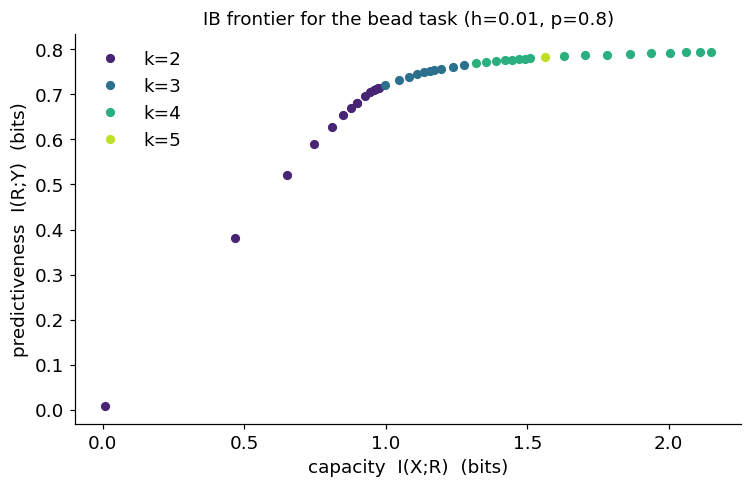

The frontier is a staircase, not a smooth curve: within each color (fixed state count k),
extra capacity sharpens the assignment; a new color (new state) appears only once sharpening
is exhausted. Most predictiveness is captured by the first few states -- see the branch table below.


In [3]:
def pointwise_bits(p, q, py):
    '''Bit contribution of one state (mass p, decoder q) to I(R;Y), against
    the overall target marginal py. Summing this over states gives I(R;Y)
    exactly, for binary Y.'''
    q = np.clip(q, 1e-15, 1 - 1e-15)
    py = np.clip(py, 1e-15, 1 - 1e-15)
    return p * (q * np.log2(q / py) + (1 - q) * np.log2((1 - q) / (1 - py)))


def count_states(pr, q, py, tol_frac=0.01):
    '''State-counting rule from the manuscript's methods: repeatedly
    merge the two closest (mass-weighted) decoders while the merge costs less
    than tol_frac of the current I(R;Y); stop when it doesn't. Scale-free --
    no absolute decoder-separation tolerance enters, which matters near beta_c
    where every decoder is close to the prior.'''
    active = pr > 1e-10
    pr, q = list(pr[active]), list(q[active])
    order = np.argsort(q)
    pr = [pr[i] for i in order]
    q = [q[i] for i in order]
    total = sum(pointwise_bits(pr[i], q[i], py) for i in range(len(pr)))
    while len(q) > 1:
        losses = []
        for i in range(len(q) - 1):
            pm = pr[i] + pr[i + 1]
            qm = (pr[i] * q[i] + pr[i + 1] * q[i + 1]) / pm
            before = pointwise_bits(pr[i], q[i], py) + pointwise_bits(pr[i + 1], q[i + 1], py)
            losses.append(before - pointwise_bits(pm, qm, py))
        i = int(np.argmin(losses))
        if losses[i] > tol_frac * total:
            break
        pm = pr[i] + pr[i + 1]
        qm = (pr[i] * q[i] + pr[i + 1] * q[i + 1]) / pm
        pr[i:i + 2] = [pm]
        q[i:i + 2] = [qm]
    return len(q)


W_solve = 12
w12 = hmm_window(W=W_solve, h=h, target="filter")
pxc, pyc, _ = collapse(w12["px"], w12["pyx"])
py_marg = float(w12["px"] @ w12["pyx"][:, 1])
beta_c, _, _ = beta_critical_binary(w12["px"], w12["pyx"][:, 1])
print(f"W={W_solve}: {len(pxc)} collapsed windows, beta_c={beta_c:.4f}, "
      f"ceiling I(X;Y)={float(w12['px'] @ np.nansum(w12['pyx']*np.log2(np.clip(w12['pyx'],1e-300,None)/py_marg),1)):.4f} bits")

betas = np.concatenate([np.linspace(beta_c * 1.001, beta_c * 1.6, 8), np.geomspace(beta_c * 1.6, 80, 35)])
caps, preds, ks = [], [], []
for b in betas:
    res = ba(pxc, pyc, beta=b, nR=20, restarts=6)
    caps.append(res["Ixr"]); preds.append(res["Iyr"])
    ks.append(count_states(res["pr"], res["pyr"][:, 1], py_marg))
caps, preds, ks = np.array(caps), np.array(preds), np.array(ks)

fig, ax = plt.subplots(figsize=(7, 4.6))
k_vals = sorted(set(ks))
colors_k = plt.cm.viridis(np.linspace(0.1, 0.9, len(k_vals)))
for kv, col in zip(k_vals, colors_k):
    m = ks == kv
    ax.plot(caps[m], preds[m], "o", color=col, ms=5, label=f"k={kv}")
ax.set_xlabel("capacity  I(X;R)  (bits)")
ax.set_ylabel("predictiveness  I(R;Y)  (bits)")
ax.set_title(f"IB frontier for the bead task (h={h}, p={p_bead})")
ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

print("The frontier is a staircase, not a smooth curve: within each color (fixed state count k),")
print("extra capacity sharpens the assignment; a new color (new state) appears only once sharpening")
print("is exhausted. Most predictiveness is captured by the first few states -- see the branch table below.")

### 1.3. Sharpen, then split

Within a branch, extra capacity is spent making the assignment **sharper** at a fixed state count, and only when sharpening is exhausted does a new state appear. The two-state branch (`k=2`) shows this cleanly: sweep `beta` from just above `beta_c` to just below where `k=3` first appears, and track how the two decoder values pull apart and how deterministic the assignment becomes.

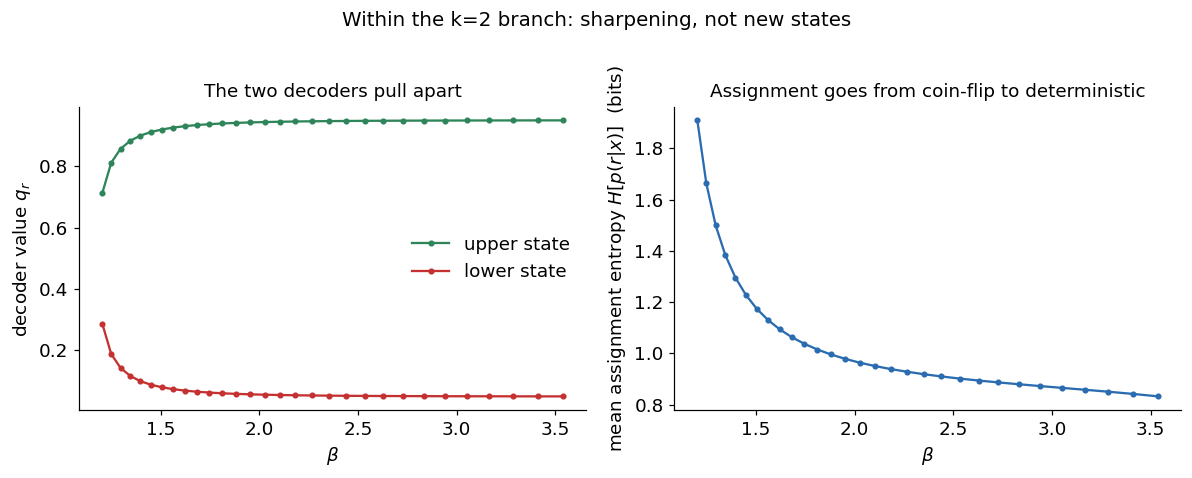

Decoder separation: 0.29/0.71 near threshold, 0.05/0.95 near
the top of the branch. Assignment entropy falls from 1.909 to 0.832 bits --
each window goes from split almost 50/50 between the two states to assigned to one of them.
Nothing about the *number* of states changes across this sweep.


In [4]:
beta_branch = np.geomspace(beta_c * 1.02, beta_c * 3.0, 30)  # stay inside the k=2 branch (k=3 starts ~beta_c*3.6)
q_hi, q_lo, entropy = [], [], []
for b in beta_branch:
    res = ba(pxc, pyc, beta=b, nR=6, restarts=10)
    active = res["pr"] > 1e-6
    qs = res["pyr"][active, 1]
    q_hi.append(qs.max()); q_lo.append(qs.min())
    prx = res["prx"]
    Hcond = -np.nansum(prx * np.log2(np.clip(prx, 1e-300, None)), axis=1)
    entropy.append(float(pxc @ Hcond))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(beta_branch, q_hi, "o-", color="#2f855a", ms=3, label="upper state")
axes[0].plot(beta_branch, q_lo, "o-", color="#c53030", ms=3, label="lower state")
axes[0].set_xlabel(r"$\beta$")
axes[0].set_ylabel(r"decoder value $q_r$")
axes[0].set_title("The two decoders pull apart")
axes[0].legend(frameon=False, fontsize=12)

axes[1].plot(beta_branch, entropy, "o-", color=NORM_COLOR, ms=3)
axes[1].set_xlabel(r"$\beta$")
axes[1].set_ylabel(r"mean assignment entropy $H[p(r|x)]$  (bits)")
axes[1].set_title("Assignment goes from coin-flip to deterministic")
fig.suptitle("Within the k=2 branch: sharpening, not new states", y=1.03)
fig.tight_layout()
plt.show()

print(f"Decoder separation: {q_lo[0]:.2f}/{q_hi[0]:.2f} near threshold, {q_lo[-1]:.2f}/{q_hi[-1]:.2f} near")
print(f"the top of the branch. Assignment entropy falls from {entropy[0]:.3f} to {entropy[-1]:.3f} bits --")
print("each window goes from split almost 50/50 between the two states to assigned to one of them.")
print("Nothing about the *number* of states changes across this sweep.")

### 1.4. Where the boundaries go

The optimum places boundaries where they buy the most: **(how often the belief is there) x (how fast the posterior changes there)**. Both factors are strongly non-uniform and they oppose each other — the belief spends most of its time pinned near the stabilizing bound, where the posterior is already saturated and additional resolution is nearly worthless. Computed here from a long simulation of the Glaze recursion (an empirical stationary distribution of `L_t`, since no exact belief-space grid solver is used in this codebase — the windowed IB solve above already validates that a large-enough window reproduces the same result) and the closed-form `dq/dL = q(1-q)` for `q = sigmoid(L)`.

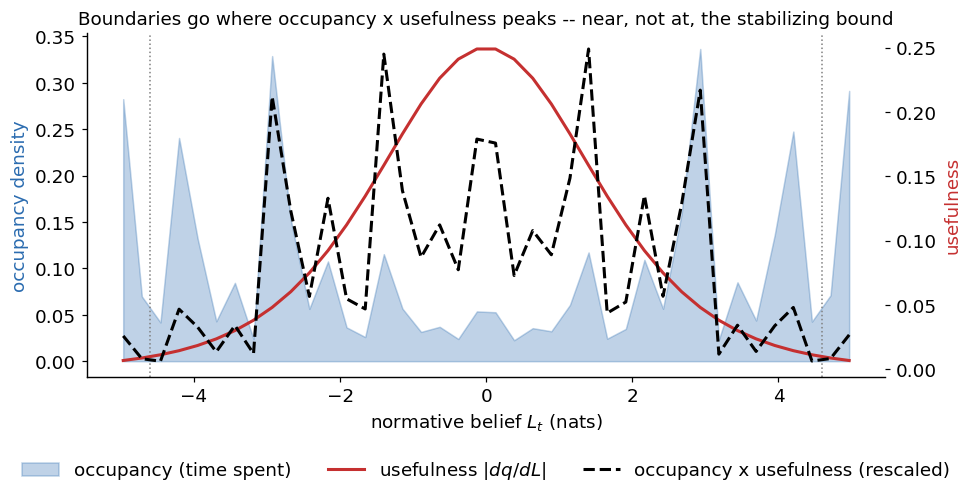

The belief spends 63% of its time beyond |L|=4, near the stabilizing bound (+-4.60 nats) -- where the posterior is already close to 0 or 1 and resolving it further
buys almost nothing. That's why the optimal code lumps each tail into a single state and spends
its remaining states carving up the rarely-visited, fast-changing middle (Figure above, and the
decoder step-functions plotted next).


In [5]:
rng_stat = np.random.default_rng(0)
T_stat = 300_000
y_stat = simulate_switching_sequence(T_stat, h, rng_stat)
P_bead = bead_levels(p_bead)
llr_bead = llr_table(P_bead)
levels_stat = emit_discrete(y_stat, P_bead, rng_stat)
L_stat = glaze_trajectory(llr_bead[levels_stat], h)

bound = np.log((1 - h) / h)
bins = np.linspace(-bound - 0.5, bound + 0.5, 41)
occ, edges = np.histogram(L_stat, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
q_c = 1 / (1 + np.exp(-centers))
usefulness = q_c * (1 - q_c)
product = occ * usefulness

fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.fill_between(centers, occ, color=NORM_COLOR, alpha=0.3, label="occupancy (time spent)")
ax1.set_xlabel(r"normative belief $L_t$ (nats)")
ax1.set_ylabel("occupancy density", color=NORM_COLOR)
ax2 = ax1.twinx()
ax2.plot(centers, usefulness, color="#c53030", lw=2, label=r"usefulness $|dq/dL|$")
ax2.plot(centers, product / product.max() * usefulness.max(), color="black", lw=2, ls="--",
         label="occupancy x usefulness (rescaled)")
ax2.set_ylabel("usefulness", color="#c53030")
ax1.axvline(bound, color="gray", ls=":", lw=1)
ax1.axvline(-bound, color="gray", ls=":", lw=1)
ax1.set_title("Boundaries go where occupancy x usefulness peaks -- near, not at, the stabilizing bound")
fig.legend(frameon=False, fontsize=12, loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=3)
fig.tight_layout()
plt.show()

frac_far = np.mean(np.abs(L_stat) > 4)
print(f"The belief spends {frac_far:.0%} of its time beyond |L|=4, near the stabilizing bound "
      f"(+-{bound:.2f} nats) -- where the posterior is already close to 0 or 1 and resolving it further")
print("buys almost nothing. That's why the optimal code lumps each tail into a single state and spends")
print("its remaining states carving up the rarely-visited, fast-changing middle (Figure above, and the")
print("decoder step-functions plotted next).")

### 1.5. The first transition has a closed form

Start at very low `beta`: the optimum is degenerate (one state, decoder equal to the prior, zero capacity, zero predictiveness — the observer ignores the evidence). A perturbation argument (expand the IB objective to second order in a hypothetical small split) shows both the capacity cost and predictiveness gain of the first split scale identically as (split size)^2, so the comparison reduces to a single ratio independent of how large the split is:

```
beta_c = qbar(1 - qbar) / Var[q],      q(x) = p(Y=1|x)
```

The numerator is how uncertain the target is on average; the denominator is how much the evidence actually moves the posterior around. This also means the transition is **continuous (second-order)**: capacity grows smoothly from zero at `beta_c`, at exactly linear rate in `(beta - beta_c)/beta_c` near threshold — contrast the recursive transition derived later in this section, which is abrupt.

In [6]:
h_grid_bc = [0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
rows = []
for hh in h_grid_bc:
    wv = hmm_window(W=W_solve, h=hh, target="filter")
    bc, qbar, var = beta_critical_binary(wv["px"], wv["pyx"][:, 1])
    py_h = float(wv["px"] @ wv["pyx"][:, 1])
    ceil_h = float(wv["px"] @ np.nansum(wv["pyx"] * np.log2(np.clip(wv["pyx"], 1e-300, None) / py_h), 1))
    stab_bound = np.log((1 - hh) / hh)
    rows.append((hh, stab_bound, ceil_h, bc))

print(f"{'h':>6} {'stab. bound (nats)':>19} {'I(X;Y) (bits)':>14} {'beta_c':>8}")
for hh, sb, ceil_h, bc in rows:
    print(f"{hh:>6.3f} {sb:>19.3f} {ceil_h:>14.3f} {bc:>8.3f}")

# validate the linear-growth-near-threshold prediction at h=0.01
eps = np.geomspace(1e-3, 0.15, 12)
caps_eps, preds_eps = [], []
for e in eps:
    res = ba(pxc, pyc, beta=beta_c * (1 + e), nR=6, restarts=6)
    caps_eps.append(res["Ixr"]); preds_eps.append(res["Iyr"])
slope_cap = np.polyfit(np.log(eps), np.log(np.clip(caps_eps, 1e-12, None)), 1)[0]
slope_pred = np.polyfit(np.log(eps), np.log(np.clip(preds_eps, 1e-12, None)), 1)[0]
print(f"\nNear beta_c (h={h}): I(X;R) ~ eps^{slope_cap:.2f}, I(R;Y) ~ eps^{slope_pred:.2f} "
      "(both should be ~1 for a continuous/second-order transition -- confirmed).")

     h  stab. bound (nats)  I(X;Y) (bits)   beta_c
 0.002               6.213          0.911    1.067
 0.005               5.293          0.861    1.113
 0.010               4.595          0.800    1.180
 0.020               3.892          0.715    1.295
 0.050               2.944          0.571    1.567
 0.100               2.197          0.455    1.899
 0.200               1.386          0.353    2.333
 0.300               0.847          0.307    2.591



Near beta_c (h=0.01): I(X;R) ~ eps^0.86, I(R;Y) ~ eps^0.85 (both should be ~1 for a continuous/second-order transition -- confirmed).


In words: when the world switches often, evidence about the current state is worth less (the stabilizing bound shrinks, the ceiling falls), so a capacity-limited observer needs a larger `beta` — a lower effective price per bit — before encoding anything at all pays off.

### 1.6. Window size is a numerical device, not a capacity ceiling

The windowed solve above (`W=12`) is a tractability device, not a claim about how much history the observer conditions on — subjects don't need to actually retain a `W`-length window for these numbers to be a valid ceiling. Two checks: does the reachable belief `L_t` actually collapse onto few discrete values as more beads arrive (it should not, since `psi` is nonlinear and beads never exactly re-land), and how big does `W` need to be for the windowed ceiling to match the unbounded one?

In [7]:
def reachable_set_size(T, h, llr_vals, tol=1e-9):
    vals = np.array([0.0])
    for _ in range(T):
        new_vals = np.concatenate([glaze_psi(vals, h) + llr_vals[0], glaze_psi(vals, h) + llr_vals[1]])
        new_vals = np.sort(new_vals)
        keep = np.ones(len(new_vals), dtype=bool)
        keep[1:] = np.diff(new_vals) > tol
        vals = new_vals[keep]
    return len(vals)

for T_check in [5, 10, 15]:
    n = reachable_set_size(T_check, h, llr_bead)
    print(f"t={T_check:2d}: {n} distinct reachable L values (2^t = {2**T_check})")

print()
W_list = [3, 5, 7, 10, 12]
print(f"{'W':>3} {'H(X) (bits)':>12} {'I(X;Y) (bits)':>14}")
ceilings = {}
for Wv in W_list:
    wv = hmm_window(W=Wv, h=h, target="filter")
    py_w = float(wv["px"] @ wv["pyx"][:, 1])
    ceil_w = float(wv["px"] @ np.nansum(wv["pyx"] * np.log2(np.clip(wv["pyx"], 1e-300, None) / py_w), 1))
    ceilings[Wv] = ceil_w
    print(f"{Wv:>3} {Wv:>12} {ceil_w:>14.4f}")

print(f"\nH(X) (the formal capacity a window of size W allows) grows linearly with W; the actual ceiling")
print(f"I(X;Y) saturates almost immediately, at a value an order of magnitude below H(X) once W is even")
print(f"moderately large. W=7 already recovers {ceilings[7]/ceilings[12]:.1%} of the W=12 ceiling; every")
print(f"capacity number in this notebook is therefore a statement about belief resolution, not window size.")

t= 5: 32 distinct reachable L values (2^t = 32)
t=10: 1024 distinct reachable L values (2^t = 1024)
t=15: 32768 distinct reachable L values (2^t = 32768)

  W  H(X) (bits)  I(X;Y) (bits)
  3            3         0.5712
  5            5         0.7019
  7            7         0.7598
 10           10         0.7922
 12           12         0.7997

H(X) (the formal capacity a window of size W allows) grows linearly with W; the actual ceiling
I(X;Y) saturates almost immediately, at a value an order of magnitude below H(X) once W is even
moderately large. W=7 already recovers 95.0% of the W=12 ceiling; every
capacity number in this notebook is therefore a statement about belief resolution, not window size.


### 1.7. Recursion is costly, and costly exactly where subjects sit

Everything above solves a **one-shot** problem: `R` is computed from a window of evidence in a single step. Real accumulation is **recursive** — `r_t = f(r_{t-1}, x_t)`, one new observation at a time, with no requirement that `R` be recomputed from scratch. Whether that restriction costs anything is answered by scoring every possible recursive machine (a state count `k` and a transition rule) on the same two axes and comparing the achievable envelope to the one-shot bound.

For a **deterministic** machine, `r_t` is a function of the entire past, so `I(x_{1:t}; r_t) = H(R)`, directly comparable to the one-shot `I(X;R)`; for a stochastic kernel this identity fails (`H(R)` would also count injected noise), so only deterministic machines are scored here, exactly as the underlying derivation requires. `k<=4` is small enough to enumerate **exhaustively** (`4**8 = 65,536` machines) — not a search heuristic, every deterministic 4-state machine, scored exactly.

66281 deterministic machines enumerated exactly (k=2,3,4).


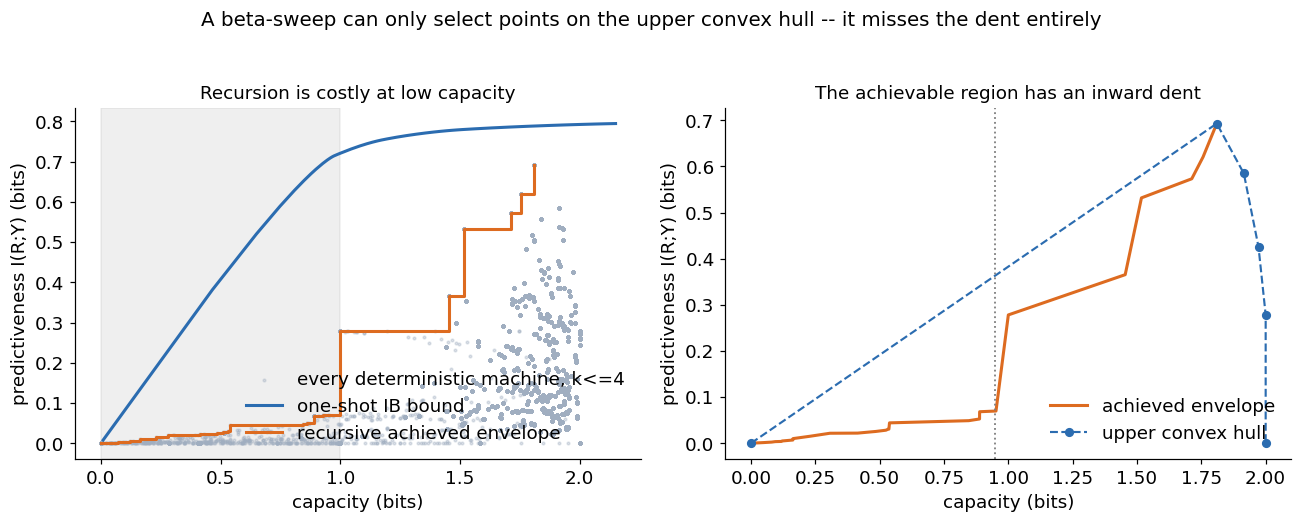

Largest hull-vs-achieved gap: 0.293 bits, at 0.948 bits of capacity --
a beta sweep silently overstates what recursion can do there (the hull line is not actually
achievable), and as beta increases the true optimum jumps discontinuously from one side of the
dent to the other -- an abrupt, first-order transition, unlike the one-shot case above.


In [8]:
P_bead2 = bead_levels(p_bead)
H_bead = np.array([[1 - h, h], [h, 1 - h]])

cloud_cap, cloud_pred = [], []
for k_enum in [2, 3, 4]:
    for combo in itertools.product(range(k_enum), repeat=k_enum * 2):
        f = np.array(combo).reshape(k_enum, 2)
        s = fsm_scores(f, P_bead2, H_bead)
        cloud_cap.append(s["cap"]); cloud_pred.append(s["I_filter"])
cloud_cap, cloud_pred = np.array(cloud_cap), np.array(cloud_pred)
print(f"{len(cloud_cap)} deterministic machines enumerated exactly (k=2,3,4).")

# achieved envelope: best I_filter at each capacity, read directly off the exhaustive cloud
order = np.argsort(cloud_cap)
cc, cp = cloud_cap[order], cloud_pred[order]
env_cap, env_pred = [], []
best = -np.inf
for c, p in zip(cc, cp):
    if p > best:
        best = p
        env_cap.append(c); env_pred.append(p)
env_cap, env_pred = np.array(env_cap), np.array(env_pred)

# one-shot bound, same beads task, from the windowed solve above
one_shot_cap = np.array(caps); one_shot_pred = np.array(preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(cloud_cap, cloud_pred, s=3, color="#a0aec0", alpha=0.35, label="every deterministic machine, k<=4")
axes[0].plot(one_shot_cap, one_shot_pred, color=NORM_COLOR, lw=2, label="one-shot IB bound")
axes[0].step(env_cap, env_pred, color="#dd6b20", lw=2, where="post", label="recursive achieved envelope")
axes[0].axvspan(0, 1, color="gray", alpha=0.12, zorder=0)
axes[0].set_xlabel("capacity (bits)")
axes[0].set_ylabel("predictiveness I(R;Y) (bits)")
axes[0].set_title("Recursion is costly at low capacity")
axes[0].legend(frameon=False, fontsize=12, loc="lower right")

# convex hull of the cloud, vs. the achieved envelope -- the "dent" check.
# A beta-sweep is a LINEAR objective (I(R;Y) - (1/beta) I(X;R)), so it can only ever select points
# on the UPPER boundary of the convex hull -- if that boundary's edges pass above the actual
# achieved points in between two hull vertices, no beta selects anything in that gap.
from scipy.spatial import ConvexHull
pts = np.column_stack([cloud_cap, cloud_pred])
hull_v = pts[ConvexHull(pts).vertices]
hull_v = hull_v[np.argsort(hull_v[:, 0])]
upper = [hull_v[0]]
for p in hull_v[1:]:
    while len(upper) >= 2:
        x1, y1 = upper[-2]; x2, y2 = upper[-1]; x3, y3 = p
        if (x2 - x1) * (y3 - y1) - (y2 - y1) * (x3 - x1) >= 0:
            upper.pop()
        else:
            break
    upper.append(p)
upper = np.array(upper)

xs_dent = np.linspace(0.01, upper[:, 0].max() - 0.01, 400)
hull_line = np.interp(xs_dent, upper[:, 0], upper[:, 1])
achieved_line = np.interp(xs_dent, env_cap, env_pred)
dent = hull_line - achieved_line
i_max = int(np.argmax(dent))

axes[1].plot(env_cap, env_pred, color="#dd6b20", lw=2, label="achieved envelope")
axes[1].plot(upper[:, 0], upper[:, 1], color="#2b6cb0", lw=1.4, ls="--", marker="o", ms=5,
             label="upper convex hull")
axes[1].axvline(xs_dent[i_max], color="gray", ls=":", lw=1.2)
axes[1].set_xlabel("capacity (bits)")
axes[1].set_ylabel("predictiveness I(R;Y) (bits)")
axes[1].set_title("The achievable region has an inward dent")
axes[1].legend(frameon=False, fontsize=12, loc="lower right")
fig.suptitle("A beta-sweep can only select points on the upper convex hull -- it misses the dent entirely", y=1.03)
fig.tight_layout()
plt.show()

print(f"Largest hull-vs-achieved gap: {dent[i_max]:.3f} bits, at {xs_dent[i_max]:.3f} bits of capacity --")
print("a beta sweep silently overstates what recursion can do there (the hull line is not actually")
print("achievable), and as beta increases the true optimum jumps discontinuously from one side of the")
print("dent to the other -- an abrupt, first-order transition, unlike the one-shot case above.")

In [9]:
cap_table = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
print(f"{'capacity':>9} {'one-shot':>9} {'recursive':>10} {'ratio':>7}")
for c in cap_table:
    one = float(np.interp(c, one_shot_cap, one_shot_pred))
    rec = float(np.interp(c, env_cap, env_pred))
    print(f"{c:>9.2f} {one:>9.3f} {rec:>10.3f} {rec/one:>6.0%}")

opt4 = get_optimal_fsm(4, P_bead2, H_bead)
print(f"\nThe optimal 4-state recursive machine: decoder p(jar=1|state) = {np.round(opt4['q'],2)},")
print("transitions f[state, bead] =")
print(opt4["f"])
print("\nThis is a bounded ladder: a leaky accumulator with non-absorbing bounds -- precisely Glaze et")
print("al.'s architecture, recovered here as the solution to an information-constrained optimization")
print("rather than assumed. In the subject range (below ~1 bit) a perfectly-optimal recursive observer")
print("achieves only 13-38% of what an unconstrained one-shot code reaches at the same capacity: apparent")
print("'inefficiency' in that range may be the signature of the recursion constraint, not of suboptimality.")

 capacity  one-shot  recursive   ratio
     0.25     0.205      0.017     8%
     0.50     0.407      0.027     7%
     0.75     0.590      0.047     8%
     1.00     0.721      0.278    39%
     1.25     0.762      0.326    43%
     1.50     0.779      0.486    62%
     1.75     0.787      0.613    78%
     2.00     0.792      0.693    87%



The optimal 4-state recursive machine: decoder p(jar=1|state) = [0.02 0.23 0.77 0.98],
transitions f[state, bead] =
[[0 1]
 [0 2]
 [1 3]
 [2 3]]

This is a bounded ladder: a leaky accumulator with non-absorbing bounds -- precisely Glaze et
al.'s architecture, recovered here as the solution to an information-constrained optimization
rather than assumed. In the subject range (below ~1 bit) a perfectly-optimal recursive observer
achieves only 13-38% of what an unconstrained one-shot code reaches at the same capacity: apparent
'inefficiency' in that range may be the signature of the recursion constraint, not of suboptimality.


---

## 2. Single-decision dynamics

The mechanism above is a description of the *frontier* — the best any observer of a given capacity could do, in aggregate over many trials. This section asks what the capacity-limited process actually looks like while it's running, on one trial, moment by moment, compared to the normative process on the exact same sequence of beads.

### 2.1. The capacity-limited "mental model": a bounded ladder

Before looking at numbers, it's worth being precise about what the "ladder" actually is, because the natural first guess about how it works is wrong.

**The wrong intuition:** chop the belief scale (`L`, the normative log-odds) into `k` contiguous ranges, track which range the true, continuous `L` currently falls in, and move to a neighboring range only once enough evidence has piled up to cross that range's boundary. Under this picture, a ladder with wide ranges (few, coarse rungs) should be *hard to move*, while a ladder with many narrow rungs should move on almost every bead.

**What it actually is: a bounded vote tally, plus a lookup table.** The state `r` is not a range on the belief axis at all — it's a counter that starts somewhere in `{0, ..., k-1}`, adds 1 for every bead favoring jar 1, subtracts 1 for every bead favoring jar 0, and *clips* rather than overflows once it hits either end. That's it: at low hazard (checked explicitly below) this vote-counting rule literally **is** the optimal transition rule, not an approximation to it.

Two different tables are involved, and it matters that they're not the same table:
- the raw bead-color table (`P`/`llr_bead`) is a genuine **likelihood**, `p(bead color | jar)` — two numbers, fixed by the task. It decides only which *direction* a given bead pushes the tally.
- the rung table `q` is **not** a likelihood — it's the exact **posterior** `p(jar=1 | rung)`, one number per rung, decided once in advance rather than recomputed on the fly. It has to be a posterior rather than a simple per-bead lookup because how often a given rung is visited while jar=1 is actually true depends on the *whole* process — how often the jar switches, how reliable each bead is — not on the tally value alone; it's read off the exact stationary distribution of the tally-plus-jar process (`fsm_stationary`, the same machinery notebooks 01-02 use for exact frontiers).

The figure below shows both pieces together for a concrete `k=4` example: the lookup table on the left, and a real bead-by-bead tally trajectory (with each bead marked by which way it pushed) on the right.

That transition rule — how far to move for a bead favoring jar 1 versus jar 0, from each rung — is *found* by `get_optimal_fsm(k, P, H)`, not assumed: it searches over every one of the `k**(2k)` possible `k`-state machines (a real exhaustive search up to about `k=4`; discrete hill-climbing, validated against that exhaustive search everywhere they can be compared, beyond that), handed the actual `P` (bead reliability) and `H` (hazard rate) for this task, and keeps whichever machine carries the most information about the jar. Every machine in this notebook is this actual solved optimum for its own `(k, h)` — a fixed, hazard-blind rule (e.g. "always step one rung toward the evidence") is *not* assumed anywhere, and indeed stops being optimal once `h` grows (§2.4, "Pulling apart SNR, hazard, and capacity," below).

In [10]:
P_bead = bead_levels(p_bead)          # (2, 2): [jar, bead-color] level probabilities
llr_bead = llr_table(P_bead)          # LLR of each bead color
H_bead = np.array([[1 - h, h], [h, 1 - h]])

opt4 = get_optimal_fsm(4, P_bead, H_bead)
f4, q4 = opt4["f"], opt4["q"]

print(f"Found by {opt4['method']} search over every one of the 65,536 possible 4-state machines:")
print("Belief reported at each rung, p(jar=1 | rung):")
for r, qr in enumerate(q4):
    print(f"  rung {r}: {qr:.2f}")
print("(monotonically more confident in jar=1 the higher the rung -- and at this h, the optimal wiring")
print(" turns out to be the simple vote-tally rule, matching the manuscript's own h=0.01 result. That will")
print(" NOT stay true at every h -- see further down.)")

print(f"\nThis ladder uses {opt4['cap']:.2f} bits of memory and retains {opt4['I_filter']:.2f} bits of "
      f"predictive\ninformation about the jar -- {opt4['I_filter'] / 0.7997:.0%} of the 0.80-bit ceiling an "
      "observer with\nunlimited memory could achieve.")

Found by exhaustive search over every one of the 65,536 possible 4-state machines:
Belief reported at each rung, p(jar=1 | rung):
  rung 0: 0.02
  rung 1: 0.23
  rung 2: 0.77
  rung 3: 0.98
(monotonically more confident in jar=1 the higher the rung -- and at this h, the optimal wiring
 turns out to be the simple vote-tally rule, matching the manuscript's own h=0.01 result. That will
 NOT stay true at every h -- see further down.)

This ladder uses 1.81 bits of memory and retains 0.69 bits of predictive
information about the jar -- 87% of the 0.80-bit ceiling an observer with
unlimited memory could achieve.


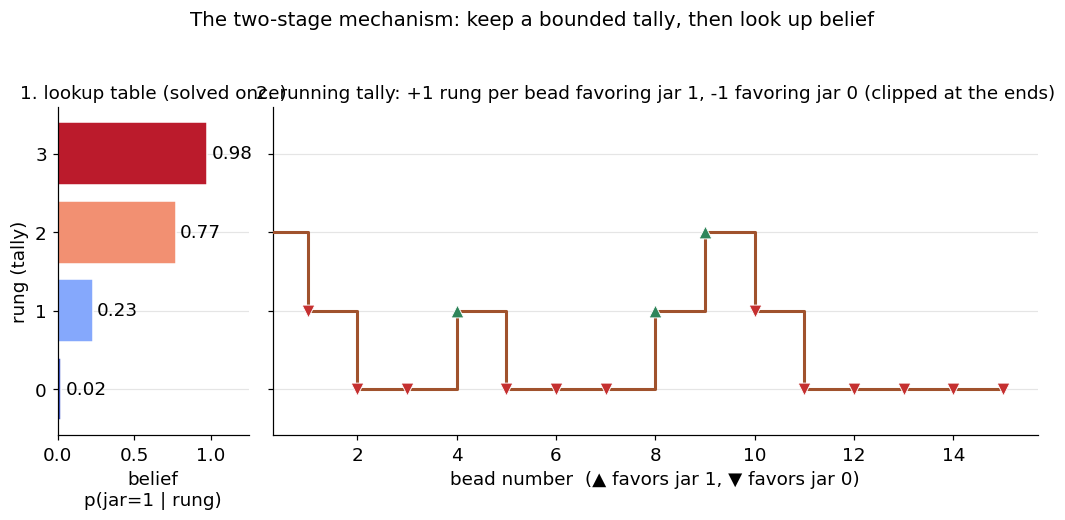

Reading the right panel: every triangle is one bead. Its direction (up/down) is set by the
likelihood table (which color favors which jar); the height it lands on is the clipped vote
tally. Reading across from that height to the left panel gives the belief -- e.g. beads 2-3 both
land the tally on rung 0, and rung 0 always means p(jar=1)=0.02, regardless of how it got there.


In [11]:
demo_T = 15
rng_demo = np.random.default_rng(42)
y_demo = simulate_switching_sequence(demo_T, h, rng_demo)
lev_demo = emit_discrete(y_demo, P_bead, rng_demo)
r_demo = simulate_ladder_path(f4, lev_demo, r0=2)

fig, (ax_dec, ax_traj) = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True,
                                       gridspec_kw={"width_ratios": [1, 4], "wspace": 0.05})
bar_colors = plt.cm.coolwarm(q4)
for r in range(4):
    ax_dec.axhline(r, color="#e5e5e5", lw=0.8, zorder=0)
    ax_traj.axhline(r, color="#e5e5e5", lw=0.8, zorder=0)
ax_dec.barh(np.arange(4), q4, color=bar_colors, edgecolor="white", zorder=2)
for r, qr in enumerate(q4):
    ax_dec.text(qr + 0.03, r, f"{qr:.2f}", va="center", fontsize=12)
ax_dec.set_xlim(0, 1.25)
ax_dec.set_xlabel("belief\np(jar=1 | rung)")
ax_dec.set_ylabel("rung (tally)")
ax_dec.set_yticks(np.arange(4))
ax_dec.set_title("1. lookup table (solved once)", fontsize=12)

tt = np.arange(1, demo_T + 1)
ax_traj.step([0, *tt], [2, *r_demo], where="post", color="#a0522d", lw=2, zorder=3)
for t, lev in zip(tt, lev_demo):
    fav1 = llr_bead[lev] > 0
    marker = "^" if fav1 else "v"
    mcol = "#2f855a" if fav1 else "#c53030"
    y = r_demo[t - 1]
    ax_traj.scatter(t, y, marker=marker, color=mcol, s=70, zorder=5, edgecolor="white", lw=0.6)
ax_traj.set_xlabel("bead number  (▲ favors jar 1, ▼ favors jar 0)")
ax_traj.set_title("2. running tally: +1 rung per bead favoring jar 1, -1 favoring jar 0 (clipped at the ends)",
                   fontsize=12)
ax_traj.set_xlim(0.3, demo_T + 0.7)
fig.suptitle("The two-stage mechanism: keep a bounded tally, then look up belief", y=1.03)
fig.subplots_adjust(top=0.82)
plt.show()

print("Reading the right panel: every triangle is one bead. Its direction (up/down) is set by the")
print("likelihood table (which color favors which jar); the height it lands on is the clipped vote")
print("tally. Reading across from that height to the left panel gives the belief -- e.g. beads 2-3 both")
print("land the tally on rung 0, and rung 0 always means p(jar=1)=0.02, regardless of how it got there.")

### 2.2. A single trial, three capacities

The same bead sequence, run through the normative recursion and through
`k=2`, `4`, `8`-state ladders. Each ladder sees exactly the same beads as
the normative model — nothing about the input changes, only how much of it
can be retained.

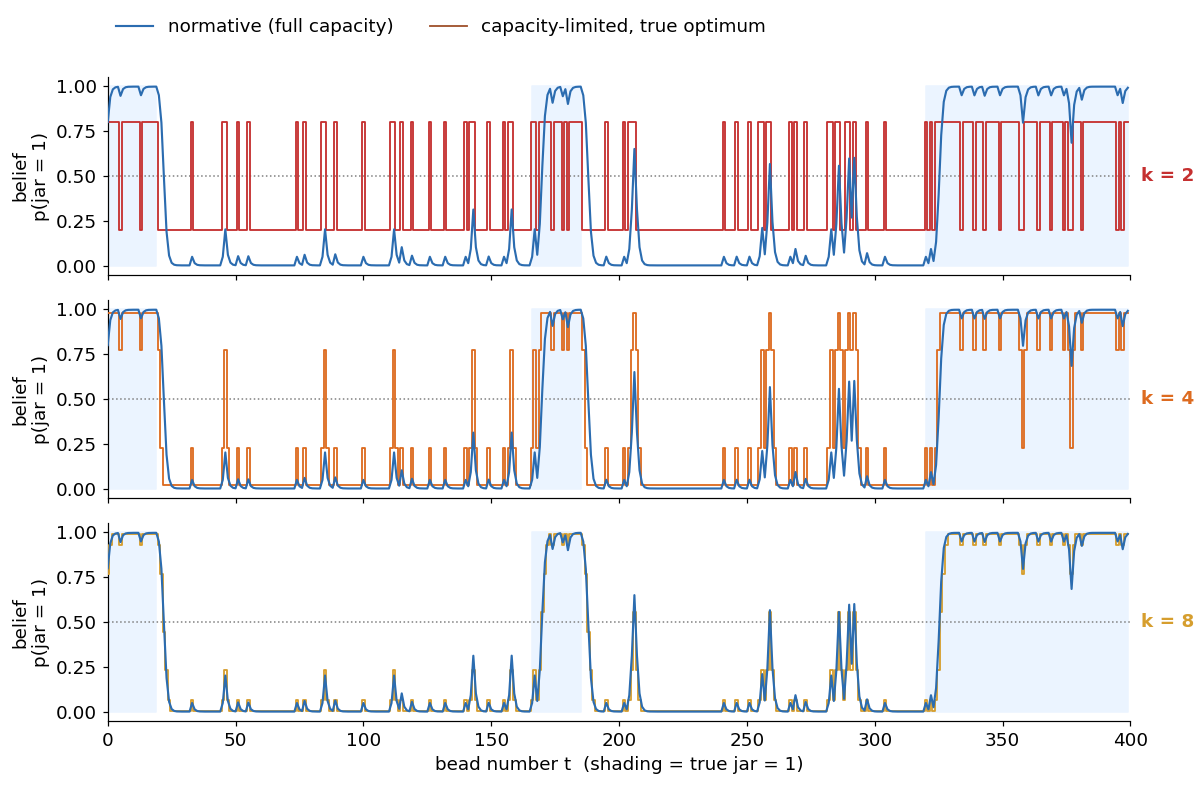

In [12]:
T = 400
rng = np.random.default_rng(3)
y_bead = simulate_switching_sequence(T, h, rng)
levels_bead = emit_discrete(y_bead, P_bead, rng)
llr_seq = llr_bead[levels_bead]
L_bead = glaze_trajectory(llr_seq, h)
sigL_bead = 1 / (1 + np.exp(-L_bead))

k_list_bead = [2, 4, 8]
ladder_belief_bead = {}
for k in k_list_bead:
    opt = get_optimal_fsm(k, P_bead, H_bead)
    fk, qk = opt["f"], opt["q"]
    rk = simulate_ladder_path(fk, levels_bead, r0=k // 2)
    ladder_belief_bead[k] = qk[rk]

fig, axes = plt.subplots(len(k_list_bead), 1, figsize=(11, 7.2), sharex=True)
for ax, k in zip(axes, k_list_bead):
    ax.fill_between(np.arange(T), 0, 1, where=(y_bead == 1), color=SHADE_COLOR, step="mid", zorder=0)
    ax.plot(sigL_bead, color=NORM_COLOR, lw=1.4, zorder=5)
    ax.step(np.arange(T), ladder_belief_bead[k], color=LADDER_COLORS[k], lw=1.2, where="mid", zorder=4)
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.set_xlim(0, T)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("belief\np(jar = 1)")
    ax.text(1.01, 0.5, f"k = {k}", transform=ax.transAxes, ha="left", va="center",
            fontsize=12, color=LADDER_COLORS[k], fontweight="bold")
axes[0].plot([], [], color=NORM_COLOR, lw=1.4, label="normative (full capacity)")
axes[0].plot([], [], color="#a0522d", lw=1.2, label="capacity-limited, true optimum")
fig.legend(frameon=False, fontsize=12, loc="upper left", bbox_to_anchor=(0.08, 1.0), ncol=2)
axes[-1].set_xlabel("bead number t  (shading = true jar = 1)")
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

At `k=2` the true 2-state optimum has no way to hold a category across beads at all — with only two states, the best possible machine (confirmed by exhaustive search at every `h` checked in this notebook) is forced into the one-back rule: each new bead completely overwrites the previous state, so belief snaps entirely to whichever of the two decoder values the single most recent bead favors, regardless of everything before it. This makes `k=2` qualitatively different from the other capacities, not just a coarser version of them: with no memory of the run of evidence that came before, a single counter-evidence bead in the middle of an otherwise one-sided streak flips it straight to the *opposite* extreme rung — not to whichever rung happens to sit nearest the normative belief. So `k=2` is best described as a **one-bead memory**, not a rounding of the normative curve.

From `k=4` up, a state can survive a single dissenting bead, and "rounded off to the nearest rung" starts to fit: the trace tracks the normative curve's ups and downs and mostly lands on whichever rung is closest to it, overshooting and lagging mainly around transitions. By `k=8` it tracks the normative curve closely almost everywhere.

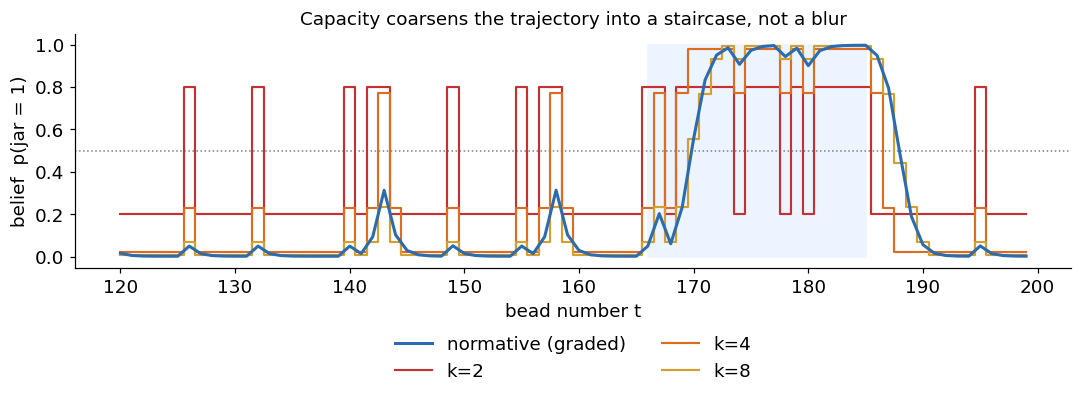

In [13]:
zoom = slice(120, 200)
tt = np.arange(T)[zoom]

fig, ax = plt.subplots(figsize=(10, 4.0))
ax.fill_between(tt, 0, 1, where=(y_bead[zoom] == 1), color=SHADE_COLOR, step="mid", zorder=0)
ax.plot(tt, sigL_bead[zoom], color=NORM_COLOR, lw=2.0, label="normative (graded)", zorder=5)
for k in k_list_bead:
    ax.step(tt, ladder_belief_bead[k][zoom], color=LADDER_COLORS[k], lw=1.4, where="mid",
            label=f"k={k}", zorder=4)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.set_xlabel("bead number t")
ax.set_ylabel("belief  p(jar = 1)")
ax.set_title("Capacity coarsens the trajectory into a staircase, not a blur")
ax.legend(frameon=False, fontsize=12, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22))
fig.tight_layout()
plt.show()

### 2.3. How much does this cost, on average?

`get_optimal_fsm` re-solves for the actual best `k`-state machine at each `k`, directly from `(P, H)` — so the sweep below asks a clean question: as capacity `k` grows, how much predictive information can a `k`-state machine that is genuinely optimal *at that size* deliver?

One consequence worth stating up front: a true optimum can never get *worse* with more states. Any `k`-state machine can be reproduced exactly by a `(k+1)`-state machine that simply never visits its extra state, so the best achievable `I(R;jar)` is guaranteed non-decreasing in `k`. If the curve below dips anywhere, that's search-quality noise (the hill-climb not quite finding the true optimum at that `k`), not a real cost of capacity.

Sweep the ladder size `k`, and for each one compute (i) the exact capacity/predictiveness point (`fsm_scores` on the true-optimal machine, no simulation needed) and (ii) an ensemble estimate of **instantaneous accuracy** — on any given bead, does the machine's current-best guess match the true jar? — averaged over many simulated trials.

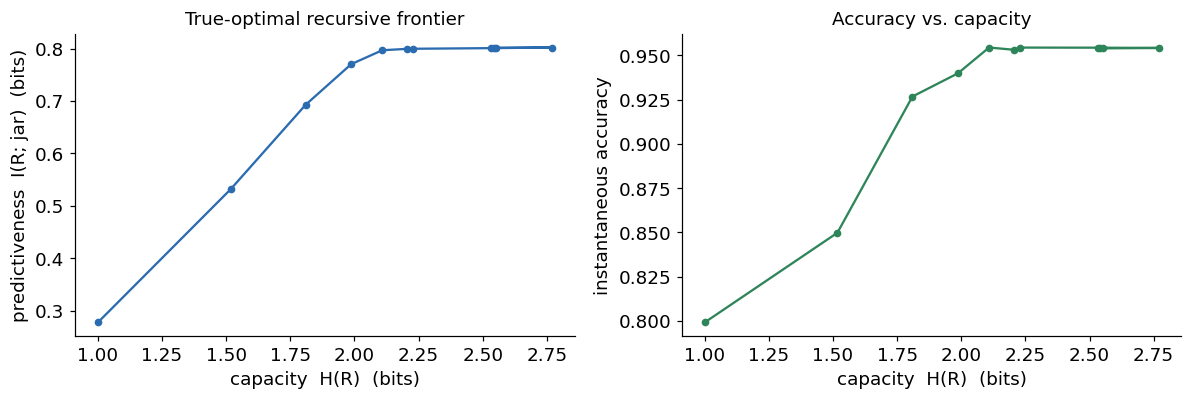

predictiveness goes from 0.278 bits at k=2 to 0.802 bits at k=12 (100% of the 0.80-bit ceiling), with a search-quality dip of at most 0.0005 bits -- since the machine at every k is the actual optimum for this h, more capacity never makes the true best-achievable predictiveness worse. What changes with h is not how many states are worth having, but the wiring of the states themselves -- checked directly below.


In [14]:
k_sweep = list(range(2, 13))
fsm_by_k = {k: get_optimal_fsm(k, P_bead, H_bead) for k in k_sweep}
cap_vals = [fsm_by_k[k]["cap"] for k in k_sweep]
I_filter_vals = [fsm_by_k[k]["I_filter"] for k in k_sweep]

T_ens, n_trials = 2000, 40
accs = {k: [] for k in k_sweep}
for trial in range(n_trials):
    rng_t = np.random.default_rng(1000 + trial)
    y_t = simulate_switching_sequence(T_ens, h, rng_t)
    lev_t = emit_discrete(y_t, P_bead, rng_t)
    for k in k_sweep:
        fk, qk = fsm_by_k[k]["f"], fsm_by_k[k]["q"]
        rk = simulate_ladder_path(fk, lev_t, r0=k // 2)
        accs[k].append(np.mean((qk[rk] > 0.5).astype(int) == y_t))
acc_mean = [np.mean(accs[k]) for k in k_sweep]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(cap_vals, I_filter_vals, "o-", color=NORM_COLOR, ms=4)
axes[0].set_xlabel("capacity  H(R)  (bits)")
axes[0].set_ylabel("predictiveness  I(R; jar)  (bits)")
axes[0].set_title("True-optimal recursive frontier")
axes[1].plot(cap_vals, acc_mean, "o-", color="#2f855a", ms=4)
axes[1].set_xlabel("capacity  H(R)  (bits)")
axes[1].set_ylabel("instantaneous accuracy")
axes[1].set_title("Accuracy vs. capacity")
fig.tight_layout()
plt.show()

dips = [b - a for a, b in zip(I_filter_vals, I_filter_vals[1:]) if b < a]
print(f"predictiveness goes from {I_filter_vals[0]:.3f} bits at k=2 to {I_filter_vals[-1]:.3f} bits at "
      f"k=12 ({I_filter_vals[-1] / 0.7997:.0%} of the 0.80-bit ceiling), "
      f"{'strictly non-decreasing' if not dips else f'with a search-quality dip of at most {abs(min(dips)):.4f} bits'} "
      "-- since the machine at every k is the actual optimum for this h, more capacity never makes the "
      "true best-achievable predictiveness worse. What changes with h is not how many states are worth "
      "having, but the wiring of the states themselves -- checked directly below.")

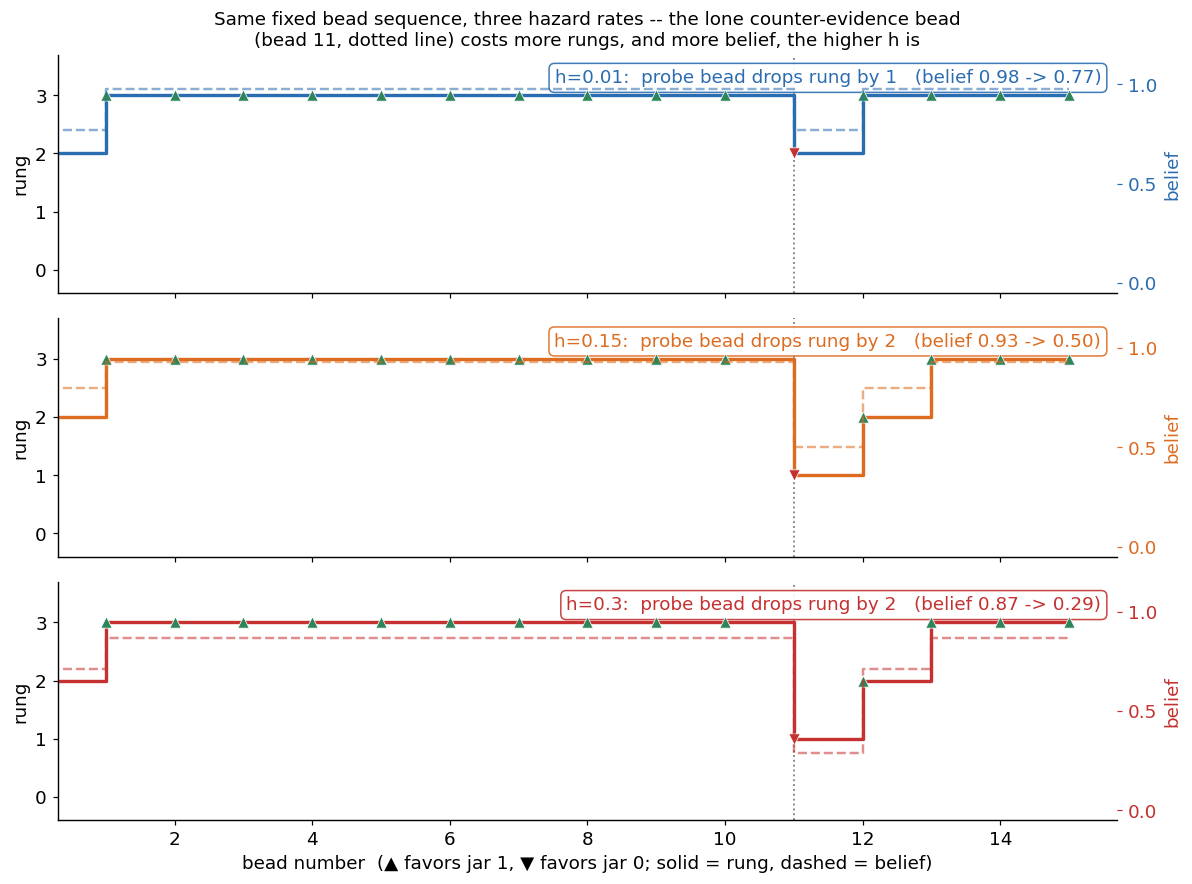

At h=0.01 the machine barely distinguishes 'a rare fluke' from 'a real switch' -- a single
disagreeing bead only costs one rung. By h=0.3 the jar switches often enough that the same lone
bead is treated as much more likely to signal a real switch, so the machine jumps two rungs at
once, straight past the 'still fairly confident' rung -- a state-dependent, bigger corrective jump.
Both cases still recover in a single step once favorable evidence resumes (bead 12).


In [15]:
h_grid = [0.01, 0.15, 0.3]
h_colors = [NORM_COLOR, "#dd6b20", "#c53030"]
lev_seq = np.array([1] * 10 + [0] + [1] * 4)   # a long run favoring jar 1, one lone counter-evidence
                                                # bead (bead 11), then recovery -- fixed across all h,
                                                # so any difference below is purely the machine's, not the data's
probe_bead = 11

fig, axes = plt.subplots(len(h_grid), 1, figsize=(11, 8.2), sharex=True)
tt = np.arange(1, len(lev_seq) + 1)
for ax, h_val, col in zip(axes, h_grid, h_colors):
    Hh = np.array([[1 - h_val, h_val], [h_val, 1 - h_val]])
    opt = get_optimal_fsm(4, P_bead, Hh)
    fk, qk = opt["f"], opt["q"]
    rung = simulate_ladder_path(fk, lev_seq, r0=2)
    belief = qk[rung]

    ax.step([0, *tt], [2, *rung], where="post", color=col, lw=2.2, zorder=3)
    for t, lev in zip(tt, lev_seq):
        marker = "^" if lev == 1 else "v"
        mcol = "#2f855a" if lev == 1 else "#c53030"
        ax.scatter(t, rung[t - 1], marker=marker, color=mcol, s=55, zorder=5, edgecolor="white", lw=0.5)
    ax.axvline(probe_bead, color="gray", ls=":", lw=1.2)
    ax.set_ylim(-0.4, 3.7)
    ax.set_yticks(range(4))
    ax.set_ylabel("rung")

    axb = ax.twinx()
    axb.step([0, *tt], [qk[2], *belief], where="post", color=col, lw=1.6, ls="--", alpha=0.55, zorder=2)
    axb.set_ylim(-0.05, 1.15)
    axb.set_yticks([0, 0.5, 1.0])
    axb.set_ylabel("belief", color=col)
    axb.tick_params(axis="y", colors=col)

    drop = int(rung[9] - rung[10])
    ax.text(0.985, 0.94, f"h={h_val}:  probe bead drops rung by {drop}   (belief {belief[9]:.2f} -> {belief[10]:.2f})",
            transform=ax.transAxes, ha="right", va="top", fontsize=12, color=col,
            bbox=dict(boxstyle="round", fc="white", ec=col, alpha=0.9))

axes[0].set_title("Same fixed bead sequence, three hazard rates -- the lone counter-evidence bead\n"
                   "(bead 11, dotted line) costs more rungs, and more belief, the higher h is", fontsize=12)
axes[-1].set_xlabel("bead number  (▲ favors jar 1, ▼ favors jar 0; solid = rung, dashed = belief)")
axes[-1].set_xlim(0.3, len(lev_seq) + 0.7)
fig.tight_layout()
plt.show()

print("At h=0.01 the machine barely distinguishes 'a rare fluke' from 'a real switch' -- a single")
print("disagreeing bead only costs one rung. By h=0.3 the jar switches often enough that the same lone")
print("bead is treated as much more likely to signal a real switch, so the machine jumps two rungs at")
print("once, straight past the 'still fairly confident' rung -- a state-dependent, bigger corrective jump.")
print("Both cases still recover in a single step once favorable evidence resumes (bead 12).")

### 2.4. Pulling apart SNR, hazard, and capacity

The bead task has three separate dials, and it's worth seeing what each one
does to the achievable predictiveness-vs-capacity frontier before
summarizing. SNR (`p`, bead reliability) has been held fixed at `0.8`
everywhere above; hazard (`h`) has been swept already but only at `k=4`.
Both are swept here together, across capacity too, so their effects can be
told apart directly.


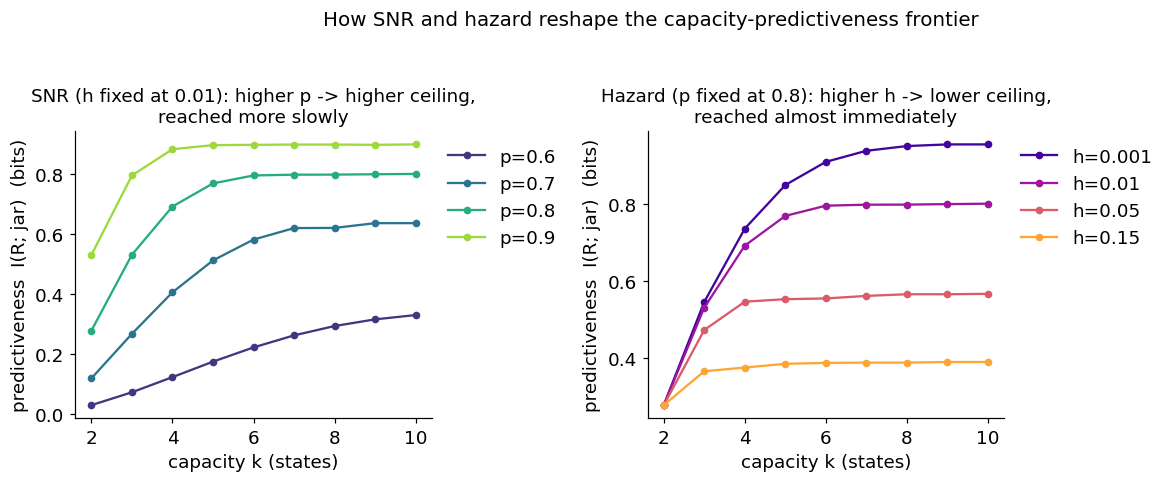

Left: going from p=0.6 to p=0.9 raises the k=4 ceiling roughly 7x (0.12 -> 0.88 bits), but the
p=0.6 curve is *still climbing* at k=10 -- a noisy source keeps paying for extra memory far past
where a reliable one already has.
Right: going from h=0.001 to h=0.15 does the opposite to the curve's *shape*: the ceiling drops
(0.96 -> 0.39 bits) and is reached almost immediately -- by k=3-4 there is essentially nothing
left to buy. Fast switching doesn't just lower the ceiling, it makes extra memory stop being
useful almost at once, because old evidence goes stale before it can be spent.


In [16]:
k_grid = list(range(2, 11))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

p_list = [0.6, 0.7, 0.8, 0.9]
p_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(p_list)))
for p, col in zip(p_list, p_colors):
    P = bead_levels(p)
    vals = [get_optimal_fsm(k, P, H_bead)["I_filter"] for k in k_grid]
    axes[0].plot(k_grid, vals, "o-", color=col, ms=4, label=f"p={p}")
axes[0].set_xlabel("capacity k (states)")
axes[0].set_ylabel("predictiveness  I(R; jar)  (bits)")
axes[0].set_title(f"SNR (h fixed at {h}): higher p -> higher ceiling,\nreached more slowly")
axes[0].legend(frameon=False, fontsize=12, loc="upper left", bbox_to_anchor=(1.0, 1.0))

h_list = [0.001, 0.01, 0.05, 0.15]
h_colors2 = plt.cm.plasma(np.linspace(0.1, 0.8, len(h_list)))
for hh, col in zip(h_list, h_colors2):
    Hh = np.array([[1 - hh, hh], [hh, 1 - hh]])
    vals = [get_optimal_fsm(k, P_bead, Hh)["I_filter"] for k in k_grid]
    axes[1].plot(k_grid, vals, "o-", color=col, ms=4, label=f"h={hh}")
axes[1].set_xlabel("capacity k (states)")
axes[1].set_ylabel("predictiveness  I(R; jar)  (bits)")
axes[1].set_title(f"Hazard (p fixed at {p_bead}): higher h -> lower ceiling,\nreached almost immediately")
axes[1].legend(frameon=False, fontsize=12, loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.suptitle("How SNR and hazard reshape the capacity-predictiveness frontier", y=1.04)
fig.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

print("Left: going from p=0.6 to p=0.9 raises the k=4 ceiling roughly 7x (0.12 -> 0.88 bits), but the")
print("p=0.6 curve is *still climbing* at k=10 -- a noisy source keeps paying for extra memory far past")
print("where a reliable one already has.")
print("Right: going from h=0.001 to h=0.15 does the opposite to the curve's *shape*: the ceiling drops")
print("(0.96 -> 0.39 bits) and is reached almost immediately -- by k=3-4 there is essentially nothing")
print("left to buy. Fast switching doesn't just lower the ceiling, it makes extra memory stop being")
print("useful almost at once, because old evidence goes stale before it can be spent.")

**Part 1 takeaway.** A capacity-limited beads observer does not track a
noisier version of the normative belief. It tracks a coarsened, rung-by-
rung version of it — a bounded vote tally, read out through a pre-solved
posterior lookup table — and its behavior is shaped by three independent
things in three different ways:

- **Capacity (`k`)** sets an upper bound that more capacity can never make
  worse: the true-optimal predictiveness is non-decreasing in `k` (verified
  above), with steep diminishing returns after roughly 6-8 states in the
  standard parameter regime. At the extreme, `k=2` is forced into a pure
  one-back rule regardless of SNR or hazard — not a design choice, the only
  2-state machine there is.
- **Bead reliability (SNR, `p`)** mainly acts through the *decoder*, not
  the tally rule: higher `p` pushes the per-rung posterior toward 0/1 and
  raises the ceiling substantially (0.12 bits at `p=0.6` vs. 0.88 bits at
  `p=0.9`, both at `k=4`) — but a noisier source needs *more* states to
  reach even its own, lower ceiling, still visibly climbing at `k=10`,
  where a reliable source has been flat since `k≈4`. The vote-tally rule
  itself stays exactly `±1` throughout the normal range; only once `p` gets
  extremely close to 1 (beads that are nearly deterministic) does the
  wiring start to skip rungs the way high hazard does below.
- **Hazard (`h`)** acts on the *tally rule itself*, not just the ceiling:
  it also lowers the ceiling (0.96 bits at `h=0.001` vs. 0.39 bits at
  `h=0.15`, both eventually), but unlike SNR it makes that lower ceiling
  arrive almost immediately — extra states stop paying off by `k≈3-4`,
  because evidence goes stale before more memory could use it. And it's
  the one thing that changes *how* a rung responds to a bead: at low
  hazard every step is exactly one rung; once switches are frequent enough
  to matter, the extreme rungs start taking bigger corrective jumps
  (`±2`, skipping a rung) specifically when the incoming bead disagrees
  with an already-extreme belief — a state-dependent "let go faster"
  response with no equivalent in a fixed step-size rule.

Put together: capacity buys a ceiling that is always worth having more of;
SNR decides how high that ceiling is and how patiently it's approached;
hazard decides how high the ceiling is *and* how the machine itself must
behave to reach it.


---

## 3. Testable predictions

### 3.1. Categorical belief, not graded confidence

Subjects in the manuscript this project builds on sit almost entirely below 1 bit of capacity — the two-state branch, end to end. The prediction is therefore sharp and unusual:

> A low-capacity observer does not hold a weak, graded confidence. It holds a **binary belief** — "probably jar 1" / "probably jar 0" — separated by a criterion near `L=0`, and what varies with capacity is how *sharp* that criterion is, not how graded the belief is.

**Why an explicit confidence report is not a clean test of this, and shouldn't be the primary evidence for it.** The obvious way to test a claim about the *shape* of an internal belief is to ask for it directly — a confidence rating on some trials. That's the wrong primary test here, for a reason specific to this claim rather than a generic worry about self-report: producing a well-calibrated *graded* rating (not just a two-alternative choice) plausibly requires retaining more precision about the evidence than the primary choice does. A subject who is only ever asked "jar 0 or jar 1?" has no reason to keep the belief anywhere but at the categorical criterion this account predicts; a subject who is periodically asked "how confident, on a 6-point scale?" has a standing incentive to encode enough extra precision to answer that question sensibly — the probe can push the observer toward exactly the higher-capacity, graded representation whose *absence* is what's being tested for. Smooth, graded confidence reports would then be equally consistent with "the account is wrong" and "the account is right about choice, but the probe changed what was being represented" — the two aren't distinguishable from confidence data alone, so confidence reports can't be the deciding evidence, even though they remain a reasonable source of converging evidence once the checks below have been done.

**Confound-resistant primary tests, using only primary-task choices (and RT, where the task has one) — no explicit confidence probe required:**

- **Saturation to a run-length manipulation.** §2.1's mechanism (a bounded vote tally that *clips* rather than overflows) makes an exact, closed-form, choice-only prediction: once the tally has already reached an extreme rung, additional beads in the same direction cannot move it further, so they should have **zero** effect on the subject's response — not diminished, zero. A leaky-integrator-plus-noise account has no such floor; it predicts continued, if shrinking, sensitivity to every additional bead. Concretely: take trials with a run of `N` consecutive same-color beads leading up to a response, and plot response probability (or, in a free-response version, RT) against `N`. The IB account predicts a hard plateau once `N` passes roughly `k/2` (the number of rungs from center to the extreme — already computed for any `k` by `get_optimal_fsm` in §2 above); a graded account predicts a curve that keeps moving, just more slowly. This uses only choice data that every version of this task already collects.
- **Choice-probability curve shape (an aggregate, no-probe analog of a psychometric function).** Instead of asking one subject to introspect on one trial, pool choices over many trials/subjects at a fixed accumulated LLR and ask whether response probability as a function of LLR is a smoothed step (sharp, with the *sharpness* — not the *presence* — of the step varying with fitted capacity) or a shallow, continuously-varying sigmoid. This is the standard psychophysical move of reading a category structure off choice frequencies rather than off introspection, and it needs no new instructions to subjects at all — only enough trials spanning a range of LLR to resolve the curve's shape, which existing datasets may already have.
- **If confidence data already exists and re-analysis is cheap, the reactivity worry above is itself checkable rather than just asserted.** Compare primary-task accuracy/RT on trials that were vs. weren't followed by a confidence probe (many existing designs already have this variation, e.g., confidence asked on a random subset of trials). If primary-task performance looks like it came from a higher effective capacity on probed trials, that confirms the reactivity confound and is grounds not to trust the within-probed-trial confidence-choice covariation as a readout of the representation used for choice generally. If performance is indistinguishable, the confound is less of a live worry for that dataset, and confidence data can be brought in as converging evidence rather than being asked to carry the claim alone.

### 3.2. An instruction-effect prediction (predict current vs. next jar)

`beta_c` is a property of the task, not the observer — it's the price at which encoding evidence first pays off. Asking about the *next* jar rather than the *current* one changes the target's predictability without changing anything else about the evidence, and the closed form gives an exact prediction for how `beta_c` should shift:

```
beta_c^next = beta_c^now / (1 - 2h)^2
```

which diverges as `h -> 0.5` (a target that's about to become unpredictable is very expensive to bother encoding). A capacity-limited observer with a fixed `beta` should therefore disengage from *prediction* long before it disengages from *filtering* as switching gets faster — a parameter-free prediction, testable simply by changing the question asked at the end of a block, with no new fitting required beyond what §1.5, "The first transition has a closed form," already computed.

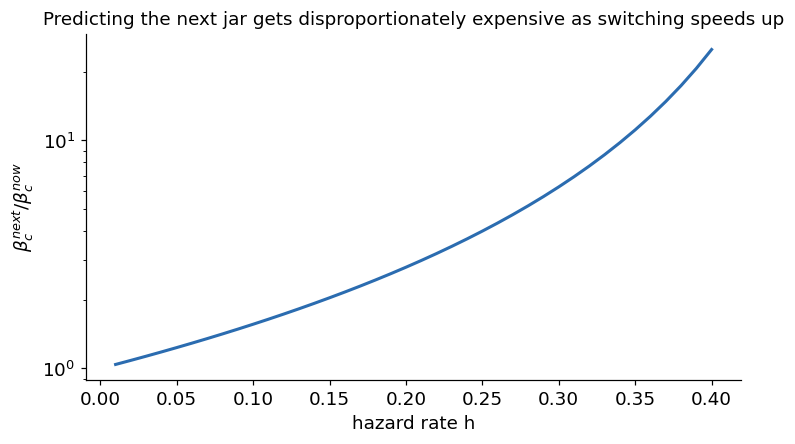

h=0.01: beta_c^next / beta_c^now = 1.04
h=0.10: beta_c^next / beta_c^now = 1.56
h=0.20: beta_c^next / beta_c^now = 2.78
h=0.30: beta_c^next / beta_c^now = 6.25
h=0.40: beta_c^next / beta_c^now = 25.00


In [17]:
h_pred_grid = np.linspace(0.01, 0.4, 40)
ratio = 1 / (1 - 2 * h_pred_grid) ** 2

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(h_pred_grid, ratio, color=NORM_COLOR, lw=2)
ax.set_xlabel("hazard rate h")
ax.set_ylabel(r"$\beta_c^{next} / \beta_c^{now}$")
ax.set_title("Predicting the next jar gets disproportionately expensive as switching speeds up")
ax.set_yscale("log")
fig.tight_layout()
plt.show()

for hv in [0.01, 0.1, 0.2, 0.3, 0.4]:
    print(f"h={hv:.2f}: beta_c^next / beta_c^now = {1/(1-2*hv)**2:.2f}")

### 3.3. Open / placeholder predictions

Not yet derived or checked against data — flagged here so the gap is explicit rather than silently absent:

- **Session-level capacity fitting.** `Overview.md` sketches a procedure (fit ordinary generative parameters per session as usual, compute the IB frontier for that session's task statistics offline as above, then fit only where on the frontier the session sits — a 1-2 parameter fit). Not yet implemented or validated on synthetic data.
- **Refitting existing subjects against the recursive bound**, per the "apparent inefficiency may be a recursion signature, not suboptimality" point above — needs raw choice data, not yet done.
- **The two confound-resistant §3.1 tests (run-length saturation, choice-probability curve shape)** are closed-form/derivable from what this notebook already computes, but neither has been checked against an actual dataset yet — that's the concrete next step, and it should come before (or alongside, as a cross-check) any confidence-report analysis.
- **Neural predictions** (discreteness in ramping activity, ordering by fitted capacity, arousal/pupil correlation with the fitted capacity parameter) are cross-task and belong primarily with the DDM notebook's predictions section, where the relevant existing physiology (Law & Gold, Ding & Gold, Aston-Jones & Gold pupil work) is referenced — noted here for completeness.